# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
  

In [ ]:
df = pd.read_csv("data/raw_data/AmesHousing.csv")

In [3]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df = df.drop(columns = ["Order", "PID"])

In [6]:
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## Seprate Feature and Target

In [7]:
X = df.drop("SalePrice", axis = 1)
y = df["SalePrice"]

## Identify Feature Types Again

In [8]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", len(numerical_features))
print("Categorical:", len(categorical_features))

Numerical: 36
Categorical: 43


C:\Users\mohsi\AppData\Local\Temp\ipykernel_24408\3025292963.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


## Missing Value Stratergies

### Strategy 1: Numerical Features

We'll use Median Imputation.

### Reason:

Robust to outliers.
Many numerical features in this dataset are skewed.
A common choice in real-world regression problems.

No need to specify columns manually. The numerical pipeline will handle all numerical features

### Strategy 2: Categorical Features Where NaN Means "Feature Doesn't Exist"

Let's create a list.

none_impute_columns = [
    "Alley",
    "Mas Vnr Type",
    "Bsmt Qual",
    "Bsmt Cond",
    "Bsmt Exposure",
    "BsmtFin Type 1",
    "BsmtFin Type 2",
    "Fireplace Qu",
    "Garage Type",
    "Garage Finish",
    "Garage Qual",
    "Garage Cond",
    "Pool QC",
    "Fence",
    "Misc Feature"
]

For these columns we'll replace missing values with:

"None"

### Strategy 3: Remaining Categorical Features

All remaining categorical features with missing values will use:

strategy="most_frequent"

because those missing values represent unknown information rather than the absence of a feature.

In [9]:
none_impute_columns = [
    "Alley",
    "Mas Vnr Type",
    "Bsmt Qual",
    "Bsmt Cond",
    "Bsmt Exposure",
    "BsmtFin Type 1",
    "BsmtFin Type 2",
    "Fireplace Qu",
    "Garage Type",
    "Garage Finish",
    "Garage Qual",
    "Garage Cond",
    "Pool QC",
    "Fence",
    "Misc Feature"
]

X[none_impute_columns] = X[none_impute_columns].fillna("None")

In [12]:
df.isnull().sum()

MS SubClass         0
MS Zoning           0
Lot Frontage      490
Lot Area            0
Street              0
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 80, dtype: int64

# Train Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
# Varify the shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2344, 79)
X_test : (586, 79)
y_train: (2344,)
y_test : (586,)


In [15]:
# Pipline for numerical feature preprocessing
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [16]:
# pipline for categorical feature preprocessing
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [17]:
# Combine both pipelines
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Model Training

### Import Regression Models

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

### Create Models Dictionary

In [21]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

### Create Results list


In [22]:
results = []

### Evaluation Function

In [28]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

def evaluate_model(model_name, pipeline, X_test, y_test):

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(
        y_test,
        y_pred
    )

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })

### Train Every Model

In [29]:
for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    evaluate_model(
        model_name,
        pipeline,
        X_test,
        y_test
    )

In [30]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="R² Score", ascending=False)

,Model,MAE,RMSE,R² Score
3,Gradient Boosting,15434.631147,26552.211568,0.912065
2,Random Forest,15697.258788,26715.034105,0.910984
0,Linear Regression,15666.332170,29106.052706,0.894336
1,Decision Tree,23762.624573,35818.786773,0.839978


# Check for Overfitting

In [32]:
best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

best_pipeline.fit(X_train, y_train)

print("Training R²:", best_pipeline.score(X_train, y_train))
print("Testing R² :", best_pipeline.score(X_test, y_test))

Training R²: 0.9605093761746116
Testing R² : 0.912065391409264


This shows very good generalization, and difference of Training R^2 and Testing R^2 is less than 5%

#  Feature Importance

### Extract the Training Model

In [33]:
gb_model = best_pipeline.named_steps["model"]

### Get Feature Names
Because we used a ColumnTransformer with OneHotEncoder, we need the transformed feature names:

In [34]:
feature_names = best_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

### Get Feature Importance

In [35]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gb_model.feature_importances_
})

### Sort

In [36]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
3,num__Overall Qual,0.519931
15,num__Gr Liv Area,0.117254
25,num__Garage Cars,0.063913
11,num__Total Bsmt SF,0.047676
8,num__BsmtFin SF 1,0.030870
12,num__1st Flr SF,0.030057
13,num__2nd Flr SF,0.028656
5,num__Year Built,0.028032
2,num__Lot Area,0.016115
18,num__Full Bath,0.014902


### Visualize

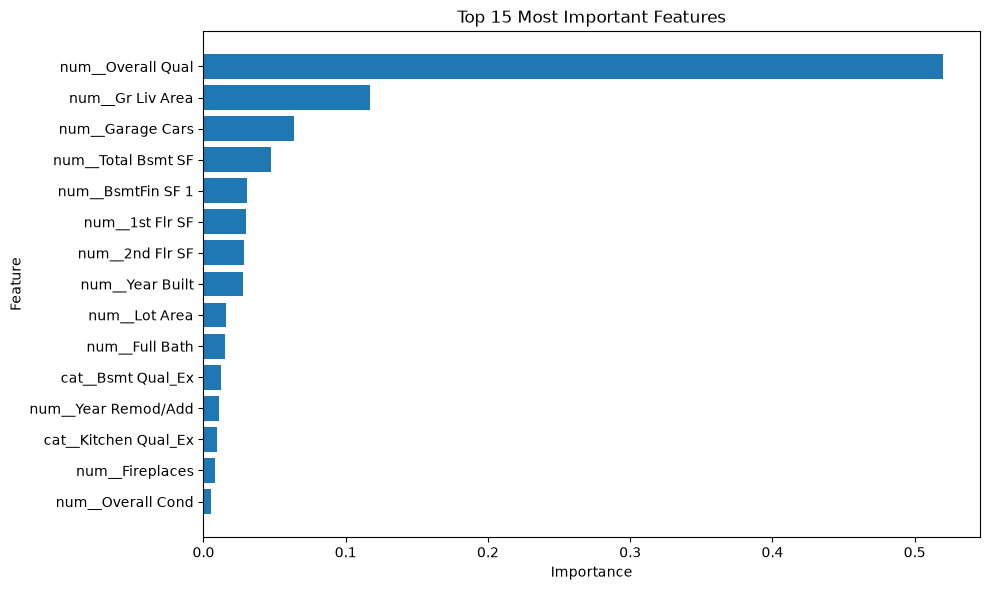

In [37]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Most Important Features")

plt.tight_layout()
plt.show()

### Feature Importance Analysis

The Gradient Boosting Regressor identified Overall Qual as the most influential predictor of house prices, which aligns with the earlier correlation analysis. Other highly important features include living area, garage capacity, basement size, and construction year. Although Neighborhood was expected to be influential, its importance is distributed across multiple one-hot encoded variables, reducing the importance of any single encoded neighborhood feature. Overall, the feature importance analysis confirms that both house quality and size are the primary drivers of house prices in this dataset.

# Saving Model
We want to save:

- Preprocessing
- Encoding
- Scaling
- Imputation
- Model

Everything together.

That's why we save the Pipeline.

In [ ]:
import joblib

joblib.dump(best_pipeline, "models/house_price_pipeline.pkl")

['C:\\Users\\mohsi\\Python\\Projects\\house_price_prediction\\models\\house_price_pipeline.pkl']

In [ ]:
loaded_pipeline = joblib.load("models/house_price_pipeline.pkl")

In [46]:
sample = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(sample)

print("Predicted Price:", prediction[0])
print("Actual Price:", y_test.iloc[0])

Predicted Price: 189950.43970676482
Actual Price: 161000


Default value, we will use median of numerical features and mode of categorical features as defualt values in app inputs, we are not going to take all 79 feature as inputs we will just take around 13 important features

In [47]:
numerical_defaults = X_train.select_dtypes(include=["int64", "float64"]).median()

categorical_defaults = X_train.select_dtypes(include=["object"]).mode().iloc[0]

default_values = pd.concat([numerical_defaults, categorical_defaults])

default_dict = default_values.to_dict()

C:\Users\mohsi\AppData\Local\Temp\ipykernel_24408\3104951977.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_defaults = X_train.select_dtypes(include=["object"]).mode().iloc[0]


In [ ]:
import joblib

joblib.dump(default_dict, "models/default_values.pkl")

['C:\\Users\\mohsi\\Python\\Projects\\house_price_prediction\\models\\default_values.pkl']

Drop down options

In [51]:
dropdown_options = {
    "Neighborhood": sorted(X_train["Neighborhood"].unique().tolist()),
    "Kitchen Qual": sorted(X_train["Kitchen Qual"].unique().tolist()),
    "Bsmt Qual": sorted(X_train["Bsmt Qual"].fillna("None").unique().tolist())
}

In [ ]:
joblib.dump(dropdown_options, "models/dropdown_options.pkl")

['C:\\Users\\mohsi\\Python\\Projects\\house_price_prediction\\models\\dropdown_options.pkl']